In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/6"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 6.2 多層ネットワーク (Multilayer Networks)

### 本節の概要と位置づけ
前節（6.1節）で確認したように、固定された基底関数の線形結合に基づくモデルは、高次元空間において「次元の呪い」という致命的な壁に直面します。この限界を打破するためのニューラルネットワークの中核的アイデアは：
> **基底関数 $\phi_j(\mathbf{x})$ 自体に調整可能なパラメータを持たせ、それらのパラメータを出力層の結合係数 $\{w_j\}$ とともに、全結合誤差関数の勾配降下法（確率的勾配降下法など）を用いてデータからエンドツーエンドで最適化する**

ことです。基底関数を微分可能なパラメータつき非線形関数とし、入力の線形結合に対して非線形変換を適用する構造を再帰的に積み重ねることで、階層的な表現学習を行う**深層ニューラルネットワーク (Deep Neural Networks)** が構築されます。

本節では、多層ネットワークの基礎理論として以下の4つの重要テーマを体系的に探求します：

1. **6.2.1 パラメータ行列 (Parameter matrices)**:
   - 2層ネットワークの数理的定式化（事前活性化 $a_j^{(1)}$、隠れユニット出力 $z_j^{(1)}$、出力事前活性化 $a_k^{(2)}$、最終出力 $y_k$）
   - バイアス吸収とパラメータ行列 $\mathbf{W}^{(1)}, \mathbf{W}^{(2)}$（数式 6.7〜6.12）
   - アーキテクチャ図版 (Figure 6.9) とパラメータ総数計算
   - 線形ボトルネックネットワークと主成分分析 (PCA) の関係
2. **6.2.2 普遍近似 (Universal approximation)**:
   - 普遍近似定理（Cybenko 1989, Hornik et al. 1989）とその本質
   - 4つの典型関数（$x^2, \sin(x), |x|, H(x)$）に対する普遍近似実験 (Figure 6.10)
   - 2クラス合成分類における隠れユニット超平面と非線形決定境界 (Figure 6.11)
   - 浅いネットワークの限界（幅の指数爆発、学習アルゴリズムの到達可能性）と深層化への動機
3. **6.2.3 隠れユニットの活性化関数 (Hidden unit activation functions)**:
   - なぜ非線形性が不可欠か（線形層の合成は単一の線形層と等価）
   - 6大活性化関数（$\tanh$, hard $\tanh$, softplus, ReLU, leaky ReLU, absolute）の数理と導関数 (Figure 6.12)
   - シグモイド系における勾配消失問題 (Vanishing Gradients) と ReLUによる解決
4. **6.2.4 重み空間の対称性 (Weight-space symmetries)**:
   - 奇関数（$\tanh$）における符号反転対称性 ($2^M$ 通り)
   - 隠れユニットの置換対称性 ($M!$ 通り)
   - 全対称性因子 $M! \cdot 2^M$ の厳密な証明と数値的不変性の検証


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの追加
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style, save_plot
from common.multilayer_networks import (
    TwoLayerMLP,
    sigmoid,
    sigmoid_deriv,
    tanh_act,
    tanh_deriv,
    hard_tanh,
    hard_tanh_deriv,
    softplus,
    softplus_deriv,
    relu,
    relu_deriv,
    leaky_relu,
    leaky_relu_deriv,
    absolute_act,
    absolute_deriv,
    compute_weight_space_symmetries,
    apply_hidden_unit_sign_flip,
    apply_hidden_unit_permutation,
    verify_weight_space_symmetry,
    generate_approximation_data,
    generate_figure_6_9,
    generate_figure_6_10,
    generate_figure_6_11,
    generate_figure_6_12,
    generate_all_section_6_2_figures,
)

setup_style()
print("Setup completed successfully.")


Setup completed successfully.


---
## 6.2.1 パラメータ行列 (Parameter Matrices)

### 2層ニューラルネットワークの数理構造
最も基本的な可変基底関数モデルとして、2つの学習可能層（パラメータ層）を持つフィードフォワード・ニューラルネットワークを考えます。入力ベクトルを $\mathbf{x} = (x_1, \dots, x_D)^T$ とします。

1. **第1層（隠れ層の事前活性化）**:
   入力変数の $M$ 個の線形結合を構成します：
   $$
   a_j^{(1)} = \sum_{i=1}^D w_{ji}^{(1)} x_i + w_{j0}^{(1)} \quad (j = 1, \dots, M) \tag{6.7}
   $$
   ここで上付き添字 $(1)$ は第1層のパラメータであることを示します。$w_{ji}^{(1)}$ を**重み (weights)**、$w_{j0}^{(1)}$ を**バイアス (biases)**、$a_j^{(1)}$ を**事前活性化 (pre-activations)** と呼びます。

2. **第1層（隠れユニットの活性化）**:
   各事前活性化 $a_j^{(1)}$ を微分可能な非線形活性化関数 $h(\cdot)$ で変換します：
   $$
   z_j^{(1)} = h(a_j^{(1)}) \tag{6.8}
   $$
   これらは線形回帰モデル (6.1) における「データ適応型基底関数」であり、ニューラルネットワークの文脈では**隠れユニット (hidden units)** と呼ばれます。

3. **第2層（出力層の事前活性化）**:
   隠れユニットの出力を再び線形結合します：
   $$
   a_k^{(2)} = \sum_{j=1}^M w_{kj}^{(2)} z_j^{(1)} + w_{k0}^{(2)} \quad (k = 1, \dots, K) \tag{6.9}
   $$
   ここで $K$ は出力変数の総数です。

4. **出力層の活性化**:
   タスク（回帰、2クラス分類、多クラス分類）に応じた適切な出力活性化関数 $f(\cdot)$ を適用して最終出力 $y_k$ を得ます：
   $$
   y_k = f(a_k^{(2)})
   $$

### バイアスの吸収とコンパクトな行列表現
第4章の線形モデルと同様に、常に $x_0 = 1$ をとるダミー入力変数を導入することで、バイアスパラメータ $w_{j0}^{(1)}$ を重みパラメータに吸収できます：
$$
a_j = \sum_{i=0}^D w_{ji}^{(1)} x_i \tag{6.10}
$$
同様に第2層のバイアスも $z_0 = 1$ として吸収すると、ネットワーク全体の写像関数は次のように1つの合成関数として表されます：
$$
y_k(\mathbf{x}, \mathbf{w}) = f\left( \sum_{j=0}^M w_{kj}^{(2)} h\left( \sum_{i=0}^D w_{ji}^{(1)} x_i \right) \right) \tag{6.11}
$$

パラメータを拡大重み行列 $\mathbf{W}^{(1)} \in \mathbb{R}^{M \times (D+1)}$ および $\mathbf{W}^{(2)} \in \mathbb{R}^{K \times (M+1)}$ にまとめると、以下の極めて簡潔なベクトル行列表現が得られます：
$$
\mathbf{y}(\mathbf{x}, \mathbf{w}) = f\left( \mathbf{W}^{(2)} h\left( \mathbf{W}^{(1)} \mathbf{x} \right) \right) \tag{6.12}
$$
ここで活性化関数 $h(\cdot)$ および $f(\cdot)$ はベクトルの各要素に個別に作用します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_9_two_layer_network.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_9_two_layer_network.png
Figure 6.9 saved to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_9_two_layer_network.png


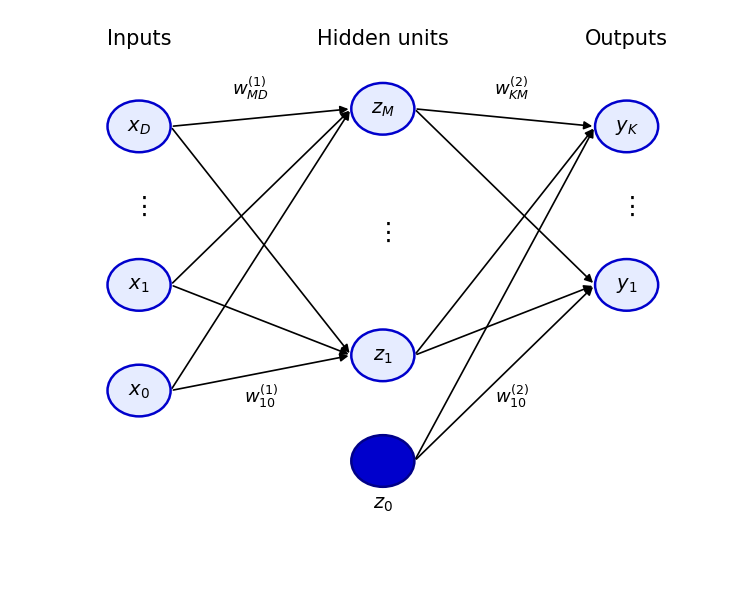

In [2]:
# Figure 6.9: 2層ニューラルネットワークのアーキテクチャ図の生成と表示
fig_6_9, paths_6_9 = generate_figure_6_9()
print(f"Figure 6.9 saved to: {paths_6_9[0]}")
plt.show()


### パラメータ総数の計算
2層ネットワークの学習可能パラメータ総数は、各層の重みとバイアスの和になります：
- 第1層: $M \times D$ 個の重み $+$ $M$ 個のバイアス $= M(D + 1)$
- 第2層: $K \times M$ 個の重み $+$ $K$ 個のバイアス $= K(M + 1)$
$$
\text{Total Parameters} = (D + 1)M + (M + 1)K
$$

### 線形隠れユニットとボトルネック・ネットワーク (PCA)
もし隠れユニットの活性化関数として恒等写像 $h(a) = a$（線形ユニット）を採用した場合、線形変換の合成は再び線形変換となるため、表現能力は単一の線形層 $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$ と完全に等価になります。
しかし、$M < \min(D, K)$ である場合、合成変換行列 $\mathbf{W}^{(2)}\mathbf{W}^{(1)}$ の階数は高々 $M$（ランク落ち）となり、低次元のボトルネックを通過することで次元削減が行われます。これは**主成分分析 (Principal Component Analysis: PCA)** と直接的に対応します（第16章参照）。


In [3]:
# パラメータ総数と線形ボトルネックの階数落ちの検証
architectures = [(1, 3, 1), (2, 2, 1), (10, 20, 5), (784, 100, 10)]

print("=== ネットワーク構造とパラメータ総数 ===")
for D, M, K in architectures:
    mlp = TwoLayerMLP(n_in=D, n_hidden=M, n_out=K)
    formula_count = (D + 1) * M + (M + 1) * K
    print(f"D={D:3d}, M={M:3d}, K={K:2d} -> パラメータ数: {mlp.count_parameters():5d} (数式計算: {formula_count:5d})")

# 線形ボトルネックの階数検証
D_b, M_b, K_b = 8, 3, 6
mlp_linear = TwoLayerMLP(n_in=D_b, n_hidden=M_b, n_out=K_b, hidden_activation="linear", output_activation="linear")
mlp_linear.init_weights(random_state=42)

W_effective = mlp_linear.W2 @ mlp_linear.W1  # (K, D) = (6, 8)
rank = np.linalg.matrix_rank(W_effective)
print(f"\nボトルネック階数検証 (D={D_b}, M={M_b}, K={K_b}):")
print(f"合成行列 W_effective の形状: {W_effective.shape}, 階数 (Rank): {rank} (理論上限: min(D,M,K)={M_b})")


=== ネットワーク構造とパラメータ総数 ===
D=  1, M=  3, K= 1 -> パラメータ数:    10 (数式計算:    10)
D=  2, M=  2, K= 1 -> パラメータ数:     9 (数式計算:     9)
D= 10, M= 20, K= 5 -> パラメータ数:   325 (数式計算:   325)
D=784, M=100, K=10 -> パラメータ数: 79510 (数式計算: 79510)

ボトルネック階数検証 (D=8, M=3, K=6):
合成行列 W_effective の形状: (6, 8), 階数 (Rank): 3 (理論上限: min(D,M,K)=3)


---
## 6.2.2 普遍近似 (Universal Approximation)

### 普遍近似定理の理論的枠組み
2層フィードフォワード・ニューラルネットワークの近似能力は1980年代後半に精力的に研究されました。
- **Funahashi (1989)**, **Cybenko (1989)**, **Hornik, Stinchcombe, and White (1989)**:
  シグモイド活性化関数を持つ2層ネットワークが、コンパクト集合上の任意の連続関数を任意の精度 $\epsilon > 0$ で一様近似できることを証明。
- **Leshno et al. (1993)**:
  この性質は、活性化関数が多項式でない限り、事実上**あらゆる非線形連続活性化関数**に対して成立することを拡張証明。

したがって、ニューラルネットワークは**普遍近似器 (Universal Approximators)** と呼ばれます。

### 4つの関数に対する普遍近似実験 (Figure 6.10)
テキストでは、わずか $M=3$ 個の $\tanh$ 隠れユニットを持つ2層ネットワークが、区間 $(-1, 1)$ 上で一様サンプリングされた $N=50$ 点のデータから以下の4つの異なる関数を協調して近似する様子が示されています：
- **(a) 二次関数**: $f(x) = x^2$
- **(b) 正弦波**: $f(x) = \sin(x)$
- **(c) 絶対値関数**: $f(x) = |x|$（原点で非微分）
- **(d) ヘビサイドのステップ関数**: $f(x) = H(x)$（不連続関数）

赤実線がネットワークの出力 $y(x)$、3本の破線が個々の隠れユニットの出力 $z_j(x) = \tanh(w_j^{(1)} x + b_j^{(1)})$ を表します。各隠れユニットが異なる位置と傾きで活性化し、それらの重み付き線形結合によって目標関数が驚くほど高精度に再構成される様子が観察できます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_10_universal_approximation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_10_universal_approximation.png
Figure 6.10 saved to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_10_universal_approximation.png


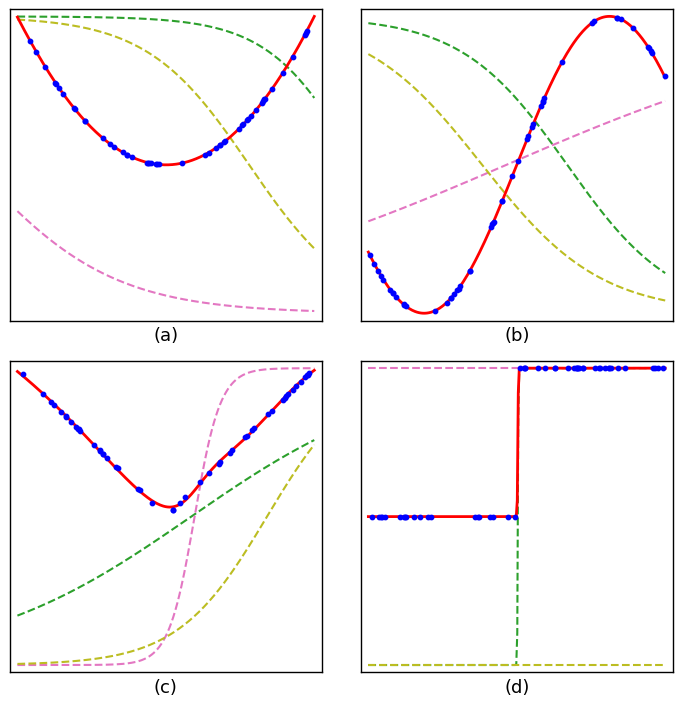

In [4]:
# Figure 6.10: 4つの異なる関数に対する普遍近似能力の実験
fig_6_10, paths_6_10 = generate_figure_6_10()
print(f"Figure 6.10 saved to: {paths_6_10[0]}")
plt.show()


### 隠れユニットの役割と非線形決定境界 (Figure 6.11)
分類問題において、隠れユニットは入力空間における**局所的な超平面（決定境界の構成要素）** を提供します。
入力2次元 $(x_1, x_2)$、隠れユニット2個（$\tanh$）、出力1個（ロジスティック・シグモイド）のネットワークを考えます：
$$
z_j = \tanh(w_{j1}^{(1)} x_1 + w_{j2}^{(1)} x_2 + w_{j0}^{(1)}) \quad (j = 1, 2)
$$
各隠れユニットの等高線 $z_j = 0.5$ は、入力空間における直線（超平面）に対応します：
$$
w_{j1}^{(1)} x_1 + w_{j2}^{(1)} x_2 + w_{j0}^{(1)} = \text{arctanh}(0.5) \approx 0.5493
$$
ネットワーク全体の決定境界 $y = 0.5$ は、出力層の事前活性化がゼロとなる曲面です：
$$
w_1^{(2)} z_1 + w_2^{(2)} z_2 + w_0^{(2)} = 0
$$
2つの隠れユニットの活性化 $z_1, z_2$ が非線形に組み合わさることで、Figure 6.11 に示すように、2本の直線（青色破線）の交差点付近で滑らかに折れ曲がる非線形な決定境界（赤色実線）が形成されます。生成分布から導出された真の最適ベイズ決定境界（緑色線）と比較しても、わずか2個の隠れユニットでベイズ境界の折れ曲がりを捉えていることが分かります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_11_classification_hidden_units.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_11_classification_hidden_units.png
Figure 6.11 saved to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_11_classification_hidden_units.png


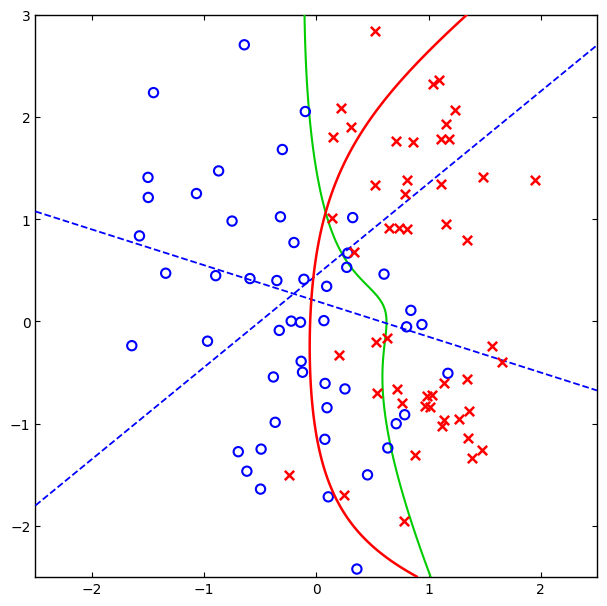

In [5]:
# Figure 6.11: 2入力2隠れユニットによる合成2クラス分類と隠れユニット超平面
fig_6_11, paths_6_11 = generate_figure_6_11()
print(f"Figure 6.11 saved to: {paths_6_11[0]}")
plt.show()


### 普遍近似定理の注意点と深層化への動機
普遍近似定理は心強い結果ですが、実用的な機械学習においては以下の重要な制約があります：
1. **存在定理にすぎない**: 目的の関数を近似できる重みの組み合わせが「存在する」ことを保証するのみで、勾配降下法などの現実の学習アルゴリズムによってその重みを発見できるかどうかについては何も述べていません。
2. **隠れユニット数の指数爆発**: 関数によっては、浅い2層ネットワークで近似するために入力次元に対して指数関数的に膨大な数の隠れユニット $M$ を必要とする場合があります。
3. **ノーフリーランチ定理 (No Free Lunch Theorem)**: 有限の訓練データからあらゆる問題に対して普遍的に優れた学習アルゴリズムは存在しません（第9章）。
4. **深層ネットワークの表現効率**: **Montúfar et al. (2014)** の理論的解析によると、ネットワークが入力空間を線形領域に分割する領域数は**層の深さに対して指数関数的**に増加しますが、層の幅に対しては多項式的にしか増加しません。したがって、同じ関数を表現するために浅い2層ネットワークでは指数関数的な数のユニットが必要であるのに対し、多層の深層ネットワークでは遥かに少ないパラメータ数で表現可能です。


---
## 6.2.3 隠れユニットの活性化関数 (Hidden Unit Activation Functions)

出力ユニットの活性化関数はモデル化する確率分布の種類（ガウス回帰なら恒等写像、2クラス分類ならシグモイド、多クラス分類ならソフトマックス）によって決定されますが、**隠れユニットの活性化関数には「微分可能であること」以外の制約がなく、多種多様な選択肢が存在します**。

テキストで解説されている代表的な非線形活性化関数を以下に整理します：

| 活性化関数 | 数式 | 特徴と利点 / 課題 |
| :--- | :--- | :--- |
| **(a) tanh** | $h(a) = \frac{e^a - e^{-a}}{e^a + e^{-a}}$ | 原点対称・ゼロ中心。シグモイドの線形変換。$|a| \gg 1$ で勾配消失。 |
| **(b) hard tanh** | $h(a) = \max(-1, \min(1, a))$ | Collobert (2004)。区分線形近似。計算効率が高い。 |
| **(c) softplus** | $h(a) = \ln(1 + e^a)$ | 平滑化されたReLU (soft ReLU)。導関数はシグモイド $\sigma(a)$。正側で勾配不消失。 |
| **(d) ReLU** | $h(a) = \max(0, a)$ | 最も広く利用される標準関数。計算極小、正側勾配1、スパース性。 |
| **(e) leaky ReLU** | $h(a) = \max(0, a) + \min(0, \alpha a)$ | $\alpha \in (0, 1)$（例: 0.2）。負側でも勾配 $\alpha$ を保持し Dying ReLU を防止。 |
| **(f) absolute** | $h(a) = \|a\|$ | leaky ReLUで $\alpha = -1$ としたもの。V字型の偶関数。 |


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_12_activation_functions.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_12_activation_functions.png
Figure 6.12 saved to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_12_activation_functions.png


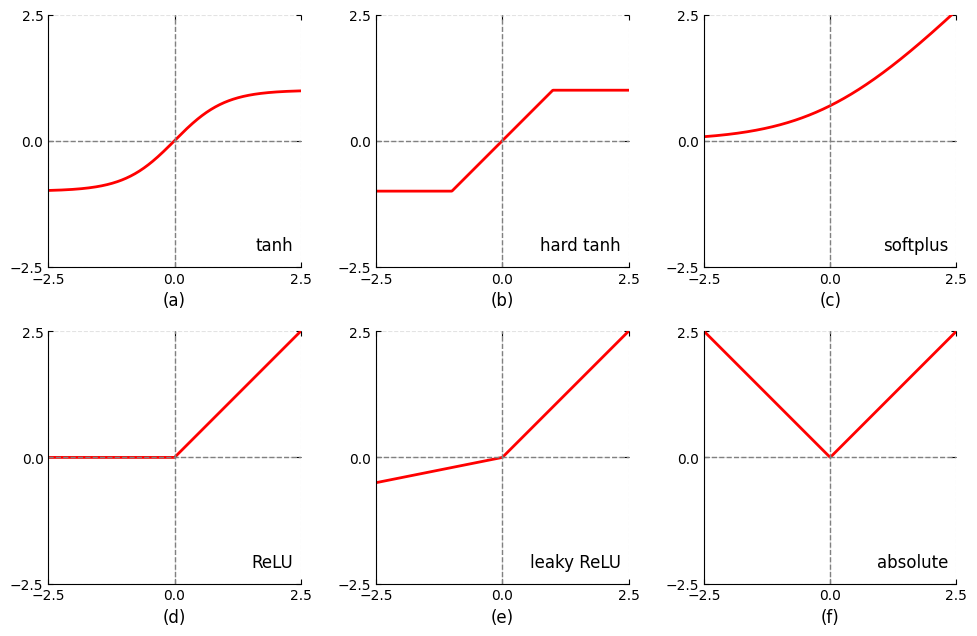

In [6]:
# Figure 6.12: 6種類の非線形活性化関数のプロット比較
fig_6_12, paths_6_12 = generate_figure_6_12()
print(f"Figure 6.12 saved to: {paths_6_12[0]}")
plt.show()


### 勾配消失問題 (Vanishing Gradients) と ReLU の優位性
ロジスティック・シグモイドおよび $\tanh$ の導関数は：
$$
\sigma'(a) = \sigma(a)(1 - \sigma(a)), \quad \tanh'(a) = 1 - \tanh^2(a)
$$
入力の絶対値 $|a|$ が大きくなると、導関数は指数関数的に $0$ に収束します。層が深くなると誤差逆伝播の連鎖律によって各層の勾配が掛け合わされ、浅い層の重み更新が完全に停止する**勾配消失問題**が発生します。

これに対し、**ReLU (Rectified Linear Unit)** は正の入力領域 ($a > 0$) において**導関数が常に $1$** であるため、勾配が減衰することなく多層にわたって逆伝播します（Krizhevsky, Sutskever, and Hinton, 2012）。また、重み初期化に対する頑健性、8-bit低精度計算との適合性、計算コストの低さなど、極めて多くの実用的メリットを持っています。


In [7]:
# 勾配消失の数値比較: tanh vs softplus vs ReLU
a_vals = np.array([0.0, 1.0, 2.0, 3.0, 5.0, 10.0])

print(f"{'a':>5s} | {'tanh deriv':>12s} | {'sigmoid deriv':>14s} | {'softplus deriv':>15s} | {'ReLU deriv':>10s}")
print("-" * 65)
for a in a_vals:
    d_tanh = float(tanh_deriv(np.array([a]))[0])
    d_sig = float(sigmoid_deriv(np.array([a]))[0])
    d_sp = float(softplus_deriv(np.array([a]))[0])
    d_relu = float(relu_deriv(np.array([a]))[0])
    print(f"{a:5.1f} | {d_tanh:12.4e} | {d_sig:14.4e} | {d_sp:15.6f} | {d_relu:10.1f}")


    a |   tanh deriv |  sigmoid deriv |  softplus deriv | ReLU deriv
-----------------------------------------------------------------
  0.0 |   1.0000e+00 |     2.5000e-01 |        0.500000 |        0.0
  1.0 |   4.1997e-01 |     1.9661e-01 |        0.731059 |        1.0
  2.0 |   7.0651e-02 |     1.0499e-01 |        0.880797 |        1.0
  3.0 |   9.8660e-03 |     4.5177e-02 |        0.952574 |        1.0
  5.0 |   1.8158e-04 |     6.6481e-03 |        0.993307 |        1.0
 10.0 |   8.2446e-09 |     4.5396e-05 |        0.999955 |        1.0


---
## 6.2.4 重み空間の対称性 (Weight-Space Symmetries)

フィードフォワード・ニューラルネットワークの顕著な理論的特性として、**全く異なる複数の重みパラメータベクトル $\mathbf{w}$ が、入力から出力への完全に同一の写像関数 $\mathbf{x} \mapsto \mathbf{y}(\mathbf{x}, \mathbf{w})$ を与える**という現象があります（Chen, Lu, and Hecht-Nielsen, 1993）。

### 1. 符号反転対称性 (Sign-Flip Symmetry)
隠れユニットの活性化関数が $\tanh$ などの**奇関数 ($h(-a) = -h(a)$)** である場合を考えます。
特定の隠れユニット $j$ に流入するすべての重みとバイアスの符号を反転させます：
$$
\tilde{w}_{ji}^{(1)} = -w_{ji}^{(1)} \quad (\forall i \in \{0, \dots, D\})
$$
すると、任意の入力 $\mathbf{x}$ に対するそのユニットの事前活性化の符号が反転し、$\tanh$ が奇関数であることから活性化出力の符号も反転します：
$$
\tilde{z}_j^{(1)} = \tanh(-\tilde{a}_j^{(1)}) = -z_j^{(1)}
$$
この符号反転は、その隠れユニットから**流出するすべての第2層重みの符号を同時に反転**させることで完全に相殺されます：
$$
\tilde{w}_{kj}^{(2)} = -w_{kj}^{(2)} \quad (\forall k \in \{1, \dots, K\})
$$
出力層への寄与は $(-w_{kj}^{(2)})(-z_j^{(1)}) = w_{kj}^{(2)} z_j^{(1)}$ となり、出力値は完全に不変です。
$M$ 個の隠れユニットが存在するため、符号反転の組み合わせは **$2^M$ 通り** 存在します。

### 2. 置換対称性 (Permutation Symmetry)
隠れユニットのインデックスを任意に並べ替えても（例: 隠れユニット1と隠れユニット2の流入・流出重みを丸ごと入れ替える）、出力層での総和 $\sum_{j=1}^M w_{kj}^{(2)} z_j^{(1)}$ の順序が変わるだけであるため、ネットワークの入出力写像は完全に不変です。
$M$ 個のユニットの並べ替えは **$M!$ 通り** 存在します。

### 全対称性因子 (Total Symmetry Factor)
符号反転と置換を組み合わせると、任意の重みベクトル $\mathbf{w}$ に対して、入出力関係が全く同一である等価な重みベクトルの総数は：
$$
\text{Total Symmetry Factor} = M! \cdot 2^M
$$
となります。隠れ層が $L$ 層ある深層ネットワークの場合、各層の隠れユニット数を $M_l$ とすると、全体の対称性因子は各層の積になります：
$$
\prod_{l=1}^L M_l! \cdot 2^{M_l}
$$

> **活性化関数による違い**:
> ReLUなどの非奇関数の場合、符号反転対称性は成り立ちませんが（$\text{ReLU}(-a) \ne -\text{ReLU}(a)$）、**$M!$ 通りの置換対称性は常に成立**します。また、ReLUは正の斉次性 $\text{ReLU}(c \cdot a) = c \cdot \text{ReLU}(a)$ を持つため、第1層を $c$ 倍し第2層を $1/c$ 倍する連続的なスケール対称性が存在します。


In [8]:
# 重み空間対称性の厳密な数値的不変性検証
rng = np.random.default_rng(2024)
D, M, K = 3, 3, 2

# tanh ネットワークの作成
mlp_tanh = TwoLayerMLP(n_in=D, n_hidden=M, n_out=K, hidden_activation="tanh", output_activation="linear")
mlp_tanh.init_weights(random_state=2024)

# テスト入力データ
X_test = rng.normal(0, 1, (20, D))
y_base = mlp_tanh.predict(X_test)

print("=== 1. 符号反転対称性の検証 (tanh) ===")
for j in range(M):
    mlp_flip = apply_hidden_unit_sign_flip(mlp_tanh, j)
    y_flip = mlp_flip.predict(X_test)
    diff = np.max(np.abs(y_base - y_flip))
    print(f"隠れユニット {j} の符号反転後の最大出力差: {diff:.2e} (不変: {diff < 1e-12})")

print("\n=== 2. 置換対称性の検証 (tanh) ===")
# 巡回置換 [1, 2, 0]
mlp_perm = apply_hidden_unit_permutation(mlp_tanh, [1, 2, 0])
y_perm = mlp_perm.predict(X_test)
diff_perm = np.max(np.abs(y_base - y_perm))
print(f"隠れユニット置換 [1, 2, 0] 後の最大出力差: {diff_perm:.2e} (不変: {diff_perm < 1e-12})")

# 対称性因子の計算
sym_factor = compute_weight_space_symmetries(M, is_odd_activation=True)
print(f"\nM={M} 隠れユニットの全対称性因子 (M! * 2^M): {sym_factor} 通り")

print("\n=== 3. 非奇関数 (ReLU) における符号反転の非不変性検証 ===")
mlp_relu = TwoLayerMLP(n_in=D, n_hidden=M, n_out=K, hidden_activation="relu", output_activation="linear")
mlp_relu.init_weights(random_state=2024)
y_relu_base = mlp_relu.predict(X_test)

mlp_relu_flip = apply_hidden_unit_sign_flip(mlp_relu, 0)
y_relu_flip = mlp_relu_flip.predict(X_test)
diff_relu = np.max(np.abs(y_relu_base - y_relu_flip))
print(f"ReLU における符号反転後の最大出力差: {diff_relu:.4f} (不変性が崩れることを確認)")


=== 1. 符号反転対称性の検証 (tanh) ===
隠れユニット 0 の符号反転後の最大出力差: 0.00e+00 (不変: True)
隠れユニット 1 の符号反転後の最大出力差: 0.00e+00 (不変: True)
隠れユニット 2 の符号反転後の最大出力差: 0.00e+00 (不変: True)

=== 2. 置換対称性の検証 (tanh) ===
隠れユニット置換 [1, 2, 0] 後の最大出力差: 1.11e-16 (不変: True)

M=3 隠れユニットの全対称性因子 (M! * 2^M): 48 通り

=== 3. 非奇関数 (ReLU) における符号反転の非不変性検証 ===
ReLU における符号反転後の最大出力差: 0.5126 (不変性が崩れることを確認)


---
## 6.2.5 本節のまとめと次節（6.3 深層ネットワーク）への展望

### 本節で確立された重要概念の総括
1. **基底関数の学習可能性**:
   固定基底関数から可変・微分可能基底関数への転換により、入力の線形結合に対する非線形変換の連鎖としてニューラルネットワークが定式化された。
2. **2層ネットワークの数理と行列表現**:
   バイアスを重み行列に吸収することで、$\mathbf{y} = f(\mathbf{W}^{(2)} h(\mathbf{W}^{(1)}\mathbf{x}))$ という極めて洗練された簡潔な表記が得られる。
3. **普遍近似能力の実証**:
   Funahashi, Cybenko, Hornik らの定理に基づき、わずか3個の隠れユニットで $x^2, \sin(x), |x|, H(x)$ などの多様な関数を協調近似できることが確認された。
4. **活性化関数の進化**:
   シグモイドや $\tanh$ の勾配消失問題を克服するため、区分線形な ReLU や Leaky ReLU、平滑化された Softplus が導入され、深層学習の実用化を加速させた。
5. **重み空間の対称性**:
   $M$ 個の隠れユニットを持つネットワークには $M! \cdot 2^M$ 通りの等価な重みベクトルが存在し、重み空間の多峰性を生み出している。

### 次節 6.3「深層ネットワーク (Deep Networks)」への展望
2層ネットワークが普遍近似能力を持つにもかかわらず、なぜ我々は「深層」ネットワークを必要とするのでしょうか？
次節 6.3 では：
- **階層的表現 (Hierarchical representations)**: 低水準特徴（エッジ）から高水準概念（物体）への合成的帰納バイアス
- **分散表現 (Distributed representations)**: 指数関数的な概念組み合わせ能力
- **転移学習 (Transfer learning)** と **対照学習 (Contrastive learning)**
- **一般の有向非巡回グラフ (DAG) アーキテクチャとテンソル計算**

を詳細に探求し、深層学習の本質に迫ります。
